Comenzamos cargando el conjunto de datos (datos de pingüinos) e importando las bibliotecas clave que necesitaremos.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

Cargamos un conjunto de datos con datos sobre **especies de pingüinos**, eliminando por defecto las instancias que contienen valores faltantes (para esto, utilizamos la función *dropna()* de la biblioteca *pandas*).

In [2]:
import pandas as pd
penguins = pd.read_csv('https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/penguins.csv').dropna()
penguins.head()

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,6,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


Preparación de datos, entrenamiento y predicciones. Utilizaremos **k=3**, de modo que cada predicción se base en las tres instancias de entrenamiento (etiquetadas) más cercanas a cada instancia de prueba.

In [3]:
# Separate predictor variables from class label
# For predictor attributes, we only keep numerical and exclude categorical ones
X = penguins.select_dtypes(exclude=['object'])
y = penguins.species

# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=4)

# Initialize a kNN classifier, with hyperparameter 'k=3'
knn = KNeighborsClassifier(n_neighbors=3)

# Training the "model": this may lead to confusion, because KNN is an instance-based algorithm, not model based.
# However, scikit-learn still requires using the 'fit' method, because the "model"
# will be defined by the training instances themselves.
knn.fit(X_train, y_train)

# Making predictions on test data
predictions = knn.predict(X_test)

In [4]:
accuracy_score(y_test, predictions)

0.98

**HAZLO TU MISM@**: prueba otras configuraciones del hiperparámetro "k" y observa cómo afecta al comportamiento y rendimiento del clasificador.

In [5]:
# PRO TRICK: Iterate over values of k to create several kNN classifiers with different k,
# calculate each classifier accuracy and plot the accuracy of each classifier as a function of k.

import numpy as np

k_settings = np.arange(1, 9)
accuracies = np.empty(len(k_settings))

for i, k in enumerate(k_settings):
    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(X_train,y_train)

    # Accuracy on the test data: gradually each classifier accuracy to a (numpy) array of accuracies
    accuracies[i] = classifier.score(X_test, y_test)

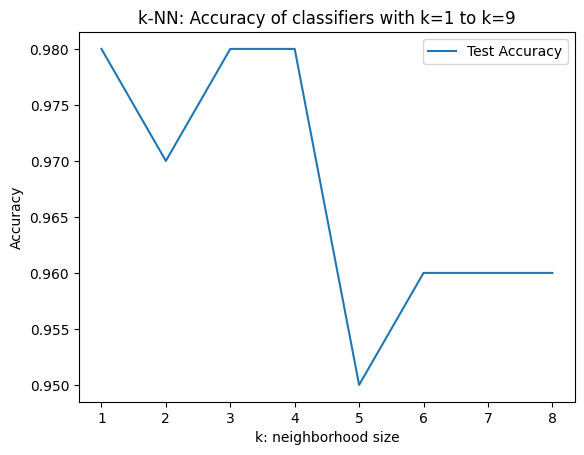

In [6]:
# CÓDIGO DE AYUDA: ¡PARA VISUALIZAR LOS RESULTADOS DE TODOS LOS CLASIFICADORES Y COMPARARLOS! (con k=1 a k=9)

import matplotlib.pyplot as plt

plt.title('k-NN: Accuracy of classifiers with k=1 to k=9')
plt.plot(k_settings, accuracies, label = 'Test Accuracy')
plt.legend()
plt.xlabel('k: neighborhood size')
plt.ylabel('Accuracy')
plt.show()